In [ ]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from matplotlib import pyplot as plt

# 🧠 Deep Learning 101: A Beginner's Guide  

## 🔍 **What is Deep Learning?**  
Deep Learning is a subfield of **Artificial Intelligence (AI)** that enables computers to learn patterns and make decisions **without explicit programming**. \
It is inspired by the structure of the human brain and is particularly effective for **image recognition, natural language processing (NLP), and autonomous systems**.  

---

## 🏗 **How Does Deep Learning Work?**  
At its core, Deep Learning relies on **Neural Networks**, which are mathematical models mimicking how the human brain processes information.  

### 📌 **Key Concepts:**  

1. **Neurons & Layers**  
   - A **neuron** takes an input, applies a mathematical function, and passes it to the next layer.  
   - A **layer** is a collection of neurons. Neural networks have:  
     - **Input Layer**: Receives raw data.  
     - **Hidden Layers**: Perform computations.  
     - **Output Layer**: Produces the final prediction.  

2. **Weights & Activation Functions**  
   - **Weights** determine how important an input is.  
   - **Activation functions** (like ReLU, Sigmoid) introduce non-linearity, allowing the network to learn complex patterns.  

3. **Forward & Backpropagation**  
   - **Forward Pass**: Data moves through the network to generate predictions.  
   - **Backpropagation**: The network adjusts its **weights** using a technique called **Gradient Descent** to reduce errors.  

# ⚔ **TensorFlow vs. PyTorch: The Ultimate Showdown**  

Deep Learning frameworks are essential tools for building and training neural networks. The two most popular ones are **TensorFlow (TF)** and **PyTorch (PT)**. While both are widely used, they have distinct philosophies and use cases. Let's compare them!  

---

## 🔥 **1. Philosophy & Usage**  
| Feature        | **TensorFlow (TF)** | **PyTorch (PT)** |
|---------------|--------------------|------------------|
| **Ease of Use** | More complex, but Keras simplifies it. | More intuitive and Pythonic. |
| **Static vs. Dynamic** | Uses static computation graphs (efficient but less flexible). | Uses dynamic computation graphs (great for research). |
| **Primary Audience** | Production, scalability, industry. | Research, experimentation, academia. |
| **Adoption** | Mainly Industry | Mainly Academia |

---

## 🏗 **2. Model Development & Flexibility**  
| Feature        | **TensorFlow (TF)** | **PyTorch (PT)** |
|---------------|--------------------|------------------|
| **Model Building API** | TensorFlow Core (low-level) or Keras (high-level). | Native PyTorch (low-level) or PyTorch Lightning (high-level). |
| **Customization** | Can be difficult due to static graphs. | Very easy due to dynamic computation graphs. |
| **Deployment** | Optimized for production with **TF Serving, TF Lite, TFX**. | Easier prototyping, but deployment requires **TorchScript** or ONNX. |

📌 **Takeaway:** TF is great for production, while PT is better for rapid experimentation.  

---

## ⚡ **3. Performance & Deployment**  
| Feature        | **TensorFlow (TF)** | **PyTorch (PT)** |
|---------------|--------------------|------------------|
| **Training Speed** | Faster for large-scale models (XLA compiler optimizations). | Slower on small-scale, but efficient for research. |
| **Scalability** | Designed for large-scale production workloads. | Less scalable, but improving with TorchServe. |
| **Mobile & Edge** | TF Lite for mobile & edge devices. | PyTorch Mobile, but less mature than TF Lite. |
| **Multi-GPU Support** | **Excellent** (TF-Distributed, Horovod). | **Good**, but requires manual setup. |

📌 **Takeaway:** TF is better for enterprise-level scaling, but PT is catching up.  

---

## 🎯 **4. Debugging & Visualization**  
| Feature        | **TensorFlow (TF)** | **PyTorch (PT)** |
|---------------|--------------------|------------------|
| **Debugging** | Harder due to static graph execution. | Easier due to eager execution. |
| **Visualization** | **TensorBoard** (best-in-class). | Integrates with TensorBoard, but less seamless. |
| **Error Messages** | Often cryptic due to graph-based execution. | More readable, Pythonic errors. |

📌 **Takeaway:** PyTorch provides better debugging, while TensorFlow has superior visualization tools.  

---

## 🏆 **5. Wrapper Libraries: Keras vs. PyTorch Lightning**  
| Feature        | **Keras (for TF)** | **PyTorch Lightning (for PT)** |
|---------------|--------------------|------------------|
| **Purpose** | Simplifies deep learning in TensorFlow. | Reduces PyTorch boilerplate code. |
| **Flexibility** | High-level API, but less customizable. | High flexibility with better structure. |
| **Ease of Use** | Beginner-friendly, great for quick prototyping. | More structured but requires PyTorch knowledge. |

📌 **Takeaway:** Keras is easier for beginners, while Lightning improves PyTorch's modularity.  

---

## 🏁 **Final Verdict: Which One Should You Choose?**  

🔹 **Use TensorFlow if:**  
✅ You need **production-ready** models.  
✅ You want **enterprise-level scalability**.  
✅ You require **mobile/edge deployment** (TF Lite).  
✅ You need **pre-built tools like TensorBoard & TFX**.  

🔹 **Use PyTorch if:**  
✅ You want **flexibility for research & experimentation**.  
✅ You prioritize **easy debugging & dynamic computation graphs**.  
✅ You work in **academia** or fast prototyping.  
✅ You need **a more Pythonic experience**.  


## Read Dataset 

In [3]:
(X, y), _ = mnist.load_data()

In [4]:
print(f"Feature set: {X.shape}, Labels: {y.shape}")

Feature set: (60000, 28, 28), Labels: (60000,)


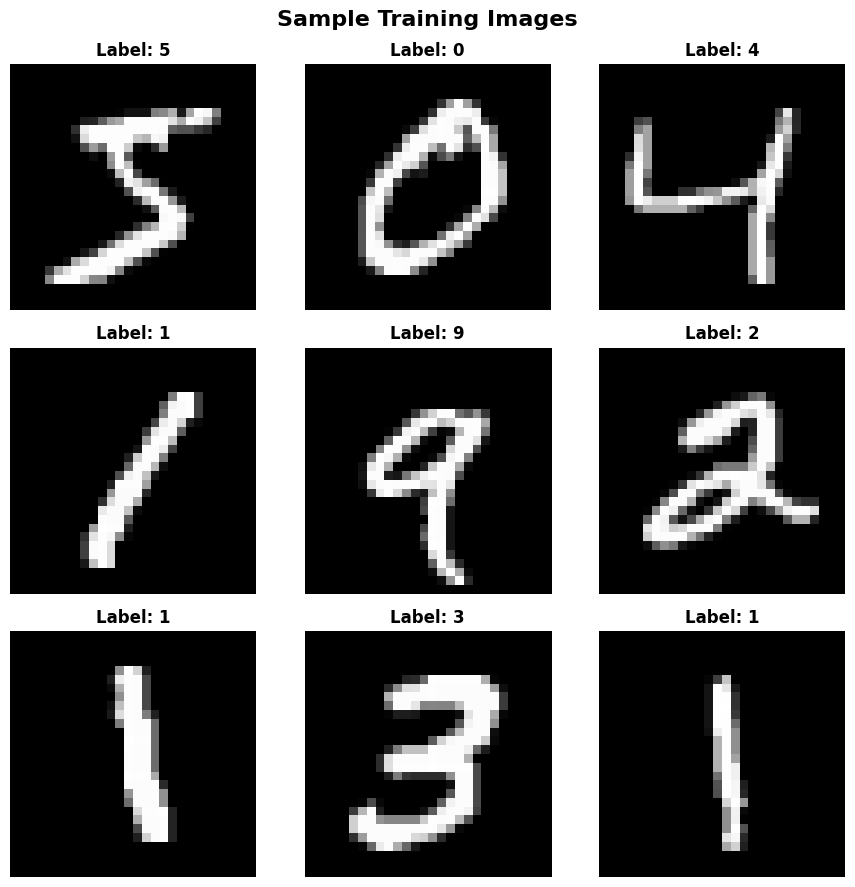

In [5]:
plt.figure(figsize=(9, 9))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    ax.imshow(X[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Label: {y[i]}", fontsize=12, fontweight="bold")
    ax.axis("off")

# Overall title for context
plt.suptitle("Sample Training Images", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### 🔍 Step 3: Exploring Image Properties
Before diving into preprocessing, let’s **inspect a single image** to better understand what we’re working with.



Shape: (28, 28)
Data Type: uint8
Min Pixel Value: 0
Max Pixel Value: 255


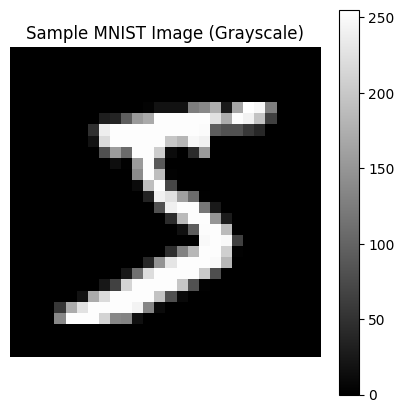

In [6]:
# Select a sample image
sample_image = X[0]

# Display its properties
print(f"Shape: {sample_image.shape}")  # (28, 28) before reshaping
print(f"Data Type: {sample_image.dtype}")  # uint8 (0-255)
print(f"Min Pixel Value: {sample_image.min()}")  # 0 (black)
print(f"Max Pixel Value: {sample_image.max()}")  # 255 (white)

# Visualize the image
fig, ax = plt.subplots(figsize=(5, 5))  # Create figure and axis
im = ax.imshow(sample_image, cmap="gray")
fig.colorbar(im, ax=ax)  # Add colorbar to the figure
ax.set_title("Sample MNIST Image (Grayscale)")
ax.axis("off")  # Remove axis ticks
plt.show()

<img src="https://i.ytimg.com/vi/fTaJZO4-Q7E/maxresdefault.jpg" style="border: 5px solid blue;">

In [7]:
# Normalize the image - why dividing by constant(s) does not "leak" data?
normalized_image = sample_image / 255.0

# Display new properties
print(f"Min Pixel Value after Normalization: {normalized_image.min()}")
print(f"Max Pixel Value after Normalization: {normalized_image.max()}")

Min Pixel Value after Normalization: 0.0
Max Pixel Value after Normalization: 1.0


#### ✅ Why Do We Normalize?
**1️⃣ Prevents Large Gradients** → Pixel values of 255 are too large compared to weights in a neural network. Scaling prevents **exploding gradients**.  
**2️⃣ Speeds Up Training** → Smaller values help the optimizer converge **faster**.  
**3️⃣ Improves Performance** → Neural networks work better when features are in a similar range.  

#### 🧠 Analogy:
Think of driving a car—if you suddenly **double** the speed, it’s harder to control. Similarly, large numbers make neural networks harder to train.

---

### 🏗 Step 5: Reshape Images

#### ✅ Why Do We Reshape?
**1️⃣ Matches Input Format for CNNs** → Convolutional Neural Networks (CNNs) expect an **additional channel dimension**\
(grayscale → 1 channel, RGB → 3 channels).

**2️⃣ Preserves Spatial Structure** → Unlike flattening, this keeps the **2D shape of the image**, allowing the model to detect patterns \
(e.g., edges, curves, digits).  

---

### Understanding Data Reshaping

#### 1. **Understanding the Dataset:**

We are working with the MNIST dataset, which contains **28x28 grayscale images of digits**. When loaded, it appears as a 3D array with the shape:

- **60000** is the number of training samples.
- Each sample is a **28x28** matrix representing the image.

#### 2. **Why Reshaping?**

For certain deep learning models, especially Convolutional Neural Networks (CNNs) or RNNs, we need to reshape the data into a format that **preserves the spatial structure** (height and width) and the **number of channels** (1 for grayscale). 

We aim to reshape the data into a format like:
(60000, 1, 28 * 28)

This reshapes the image dimensions into:
- **60000** samples (images).
- **1** channel (grayscale).
- **784** pixels (flattened 28x28 image).




In [8]:
# Step 1: Add the channel dimension
reshaped_image = np.reshape(sample_image, (1, 1, -1))
flattened_image = reshaped_image.squeeze()

print(f"Original Shape: {sample_image.shape}")
print(f"New Shape (with channel dimension): {reshaped_image.shape}")
print(f"New Shape (flattened): {flattened_image.shape}")

Original Shape: (28, 28)
New Shape (with channel dimension): (1, 1, 784)
New Shape (flattened): (784,)


In [9]:
# Apply the above transformations to the entire dataset
X_flat = np.reshape(X, (X.shape[0], 1, -1)).squeeze() / 255.0


print(f"Transformed set: {X_flat.shape}")

Transformed set: (60000, 784)


<img src="https://e2eml.school/images/image_processing/three_d_array.png">

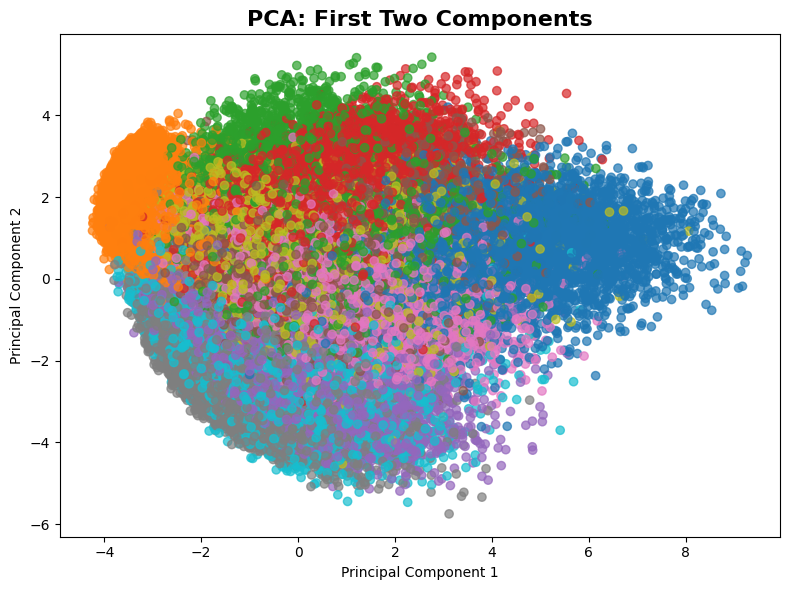

In [ ]:
# PCA sometimes produces mixed results, because it always assumes linearity... Consider altering the sub-space by using the Kernel trick (hint: KernelPCA)
from sklearn.decomposition import PCA

pca = PCA()
X_train_embed = pca.fit_transform(X_flat)
# Scatter plot of the first two PCA components
plt.figure(figsize=(8, 6))
plt.scatter(X_train_embed[:, 0], X_train_embed[:, 1], c=y, cmap="tab10", alpha=0.7)
plt.title("PCA: First Two Components", fontsize=16, fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
# plt.colorbar()
plt.tight_layout()
plt.show()

In [12]:
cum_explained_variance = pca.explained_variance_ratio_.cumsum()
tmp = np.where(cum_explained_variance >= 0.95)[0][0]

x_ticks = list(range(0, len(cum_explained_variance) + 1, 100)) + [
    len(cum_explained_variance) - 1,
    tmp,
]

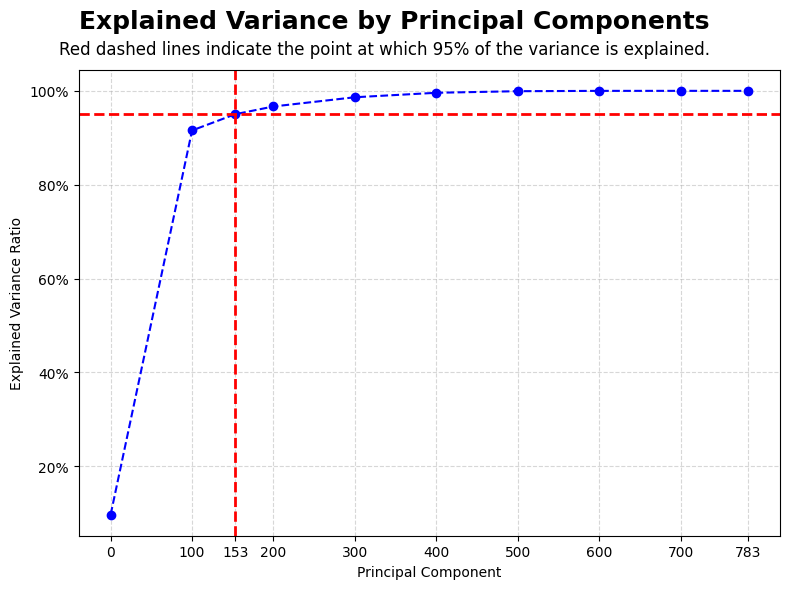

In [14]:
from matplotlib import ticker


cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()


# Define the x-tick positions (every 100th point)
tmp = np.where(cumulative_explained_variance >= 0.95)[0][0]
x_ticks = sorted(
    list(range(0, len(cumulative_explained_variance) + 1, 100))
    + [
        len(cumulative_explained_variance) - 1,
        tmp,
    ]
)

plt.figure(figsize=(8, 6))

# Get the corresponding explained variance values for those x-tick positions
y_values = cumulative_explained_variance[x_ticks]

# Plot the cumulative explained variance only at the x-tick positions
plt.plot(x_ticks, y_values, marker="o", linestyle="--", color="b")

# Highlight the threshold for 95% explained variance
plt.axhline(0.95, color="r", linestyle="--", linewidth=2)
plt.axvline(tmp, color="r", linestyle="--", linewidth=2)

# Title and labels with added subtitle for clarity
plt.title(
    "Explained Variance by Principal Components",
    fontsize=18,
    loc="left",
    fontweight="bold",
    pad=30,
)
plt.figtext(
    0.08,
    0.9,
    "Red dashed lines indicate the point at which 95% of the variance is explained.",
    fontsize=12,
    fontweight="normal",
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

# Adjust x-ticks to plot every 100th point
plt.xticks(x_ticks)

# Customize gridlines for better readability
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
# Tidy layout and show the plot
plt.tight_layout()
plt.show()

#### **Exercise:** Use the projections from [Kernel]PCA on the below experiments

## Splitting to Train-Test datasets

In [15]:
from sklearn.model_selection import train_test_split

ix = list(range(len(X_flat)))
dev_size, test_size = 0.2, 0.1

dev_slice = dev_size + test_size
test_slice = test_size / dev_size

In [16]:
ix_train, ix_dev = train_test_split(ix, test_size=dev_slice, random_state=42, stratify=y)
ix_dev, ix_test = train_test_split(
    ix_dev, test_size=test_slice, random_state=42, stratify=y[ix_dev]
)

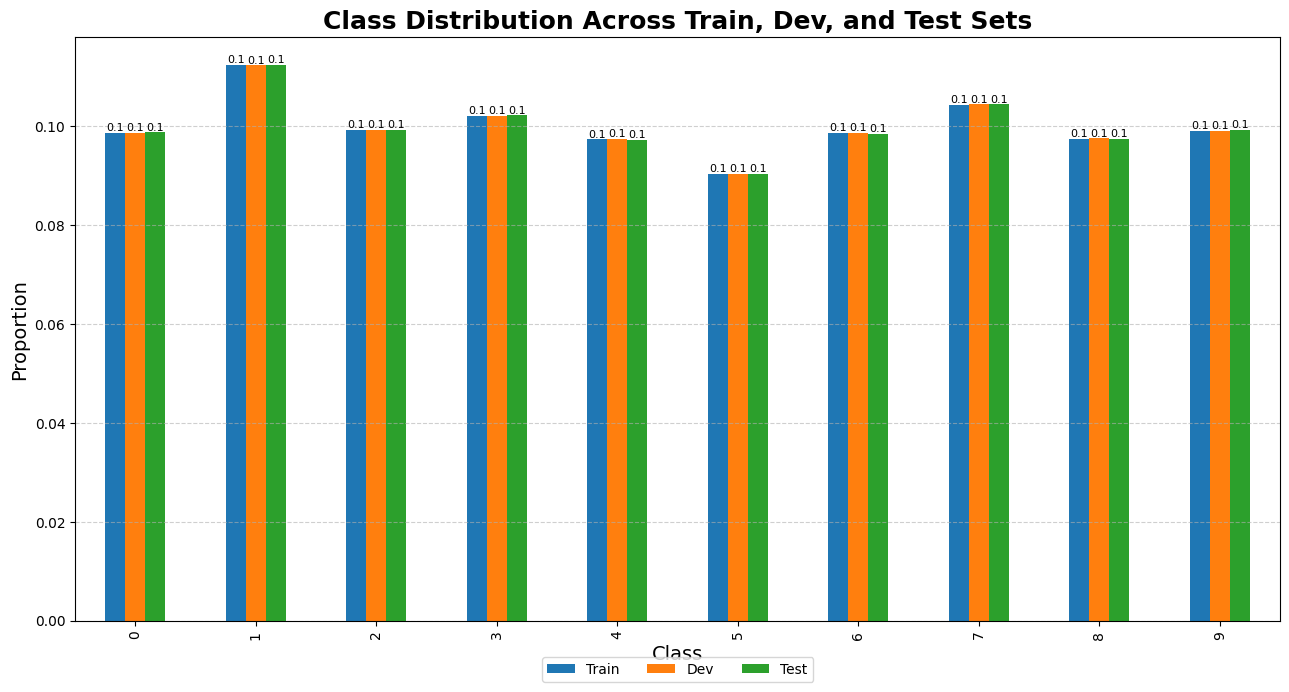

In [17]:
# Plot bar chart with value counts for train, dev, and test
fig, ax = plt.subplots(1, 1, figsize=(13, 7))

# Calculate the value counts for each split and concatenate them
df = pd.concat(
    (
        pd.Series(y[ix_train]).value_counts(normalize=True).sort_index().rename("train"),
        pd.Series(y[ix_dev]).value_counts(normalize=True).sort_index().rename("dev"),
        pd.Series(y[ix_test]).value_counts(normalize=True).sort_index().rename("test"),
    ),
    axis=1,
)

# Plot the bar chart
df.plot.bar(ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])

# Add title and labels
ax.set_title(
    "Class Distribution Across Train, Dev, and Test Sets",
    fontsize=18,
    fontweight="bold",
)
ax.set_xlabel("Class", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)

# Annotate bars with the actual percentage values
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="edge",
        fontsize=8,
        color="black",
        fmt="%.1f",
    )


# Adjust legend to be horizontal and place it below the plot
ax.legend(
    labels=["Train", "Dev", "Test"],
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
)


# Customize gridlines for readability
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

#### What if we did not use stratify?

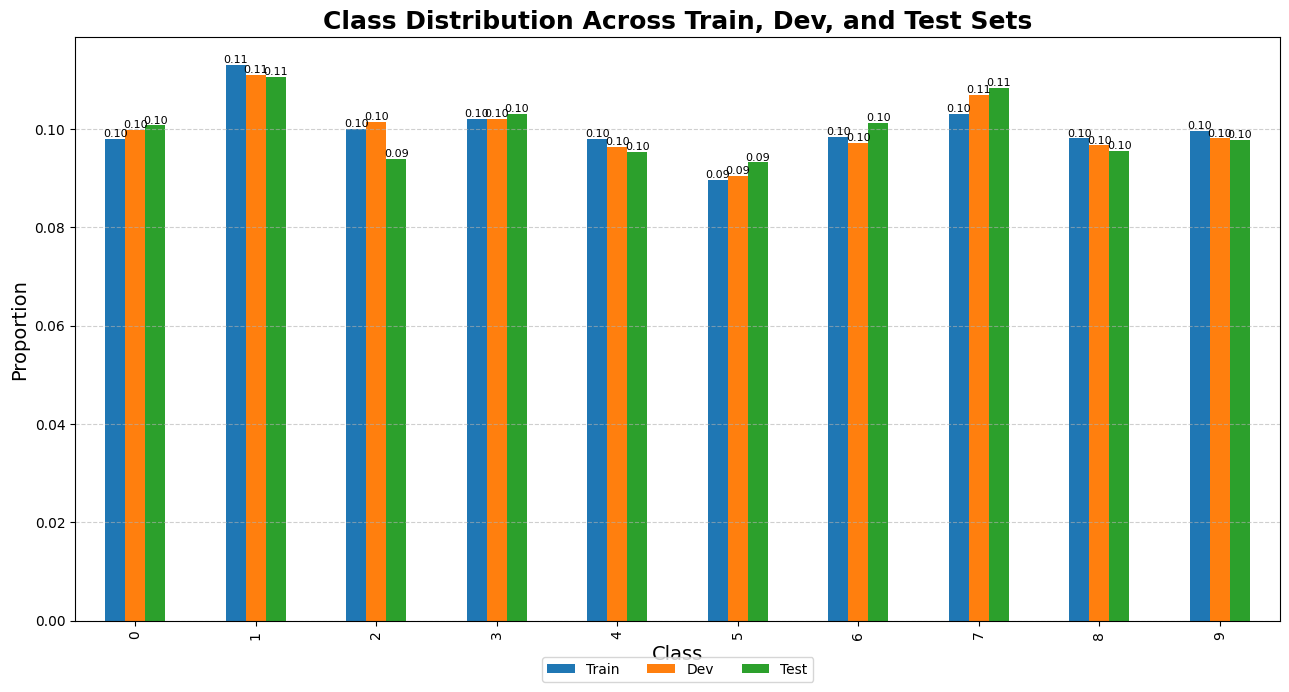

In [18]:
ix_train, ix_dev = train_test_split(ix, test_size=dev_slice, random_state=42)
ix_dev, ix_test = train_test_split(ix_dev, test_size=test_slice, random_state=42)

# Plot bar chart with value counts for train, dev, and test
fig, ax = plt.subplots(1, 1, figsize=(13, 7))

# Calculate the value counts for each split and concatenate them
df = pd.concat(
    (
        pd.Series(y[ix_train]).value_counts(normalize=True).sort_index().rename("train"),
        pd.Series(y[ix_dev]).value_counts(normalize=True).sort_index().rename("dev"),
        pd.Series(y[ix_test]).value_counts(normalize=True).sort_index().rename("test"),
    ),
    axis=1,
)

# Plot the bar chart
df.plot.bar(ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])

# Add title and labels
ax.set_title(
    "Class Distribution Across Train, Dev, and Test Sets",
    fontsize=18,
    fontweight="bold",
)
ax.set_xlabel("Class", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)

# Annotate bars with the actual percentage values
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="edge",
        fontsize=8,
        color="black",
        fmt="%.2f",
    )


# Adjust legend to be horizontal and place it below the plot
ax.legend(
    labels=["Train", "Dev", "Test"],
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
)


# Customize gridlines for readability
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

## Classifying using Decision Trees (sklearn)
##### https://github.com/edyoda/machine-learning-for-beginners/blob/master/Decision%20Tree%20-%20MNIST.ipynb

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier(
    criterion="gini", splitter="best", max_depth=5, random_state=42
).fit(X_flat[ix_train], y[ix_train])

In [20]:
clf.score(X_flat[ix_dev], y[ix_dev])

0.678

[Text(0.5, 0.9166666666666666, 'x[350] <= 0.465\ngini = 0.9\nsamples = 41999\nvalue = [4118.0, 4748.0, 4199.0, 4285.0, 4116.0, 3768.0, 4131.0\n4327.0, 4121.0, 4186.0]'),
 Text(0.25, 0.75, 'x[568] <= 0.002\ngini = 0.88\nsamples = 26838\nvalue = [3776.0, 370.0, 3317.0, 827.0, 3741.0, 2211.0, 3274.0\n3956.0, 2083.0, 3283.0]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'x[430] <= 0.002\ngini = 0.837\nsamples = 16504\nvalue = [492, 243, 635, 545, 3573, 1134, 1900, 3821, 962\n3199]'),
 Text(0.0625, 0.4166666666666667, 'x[405] <= 0.065\ngini = 0.704\nsamples = 6579\nvalue = [178.0, 236.0, 410.0, 266.0, 354.0, 351.0, 219.0, 3394.0\n560.0, 611.0]'),
 Text(0.03125, 0.25, 'x[484] <= 0.014\ngini = 0.489\nsamples = 4706\nvalue = [169, 56, 308, 57, 241, 68, 122, 3313, 16, 356]'),
 Text(0.015625, 0.08333333333333333, 'gini = 0.274\nsamples = 3794\nvalue = [95, 56, 247, 52, 10, 45, 18, 3221, 12, 38]'),
 Text(0.046875, 0.08333333333333333, 'gini = 0.779\nsamples = 912

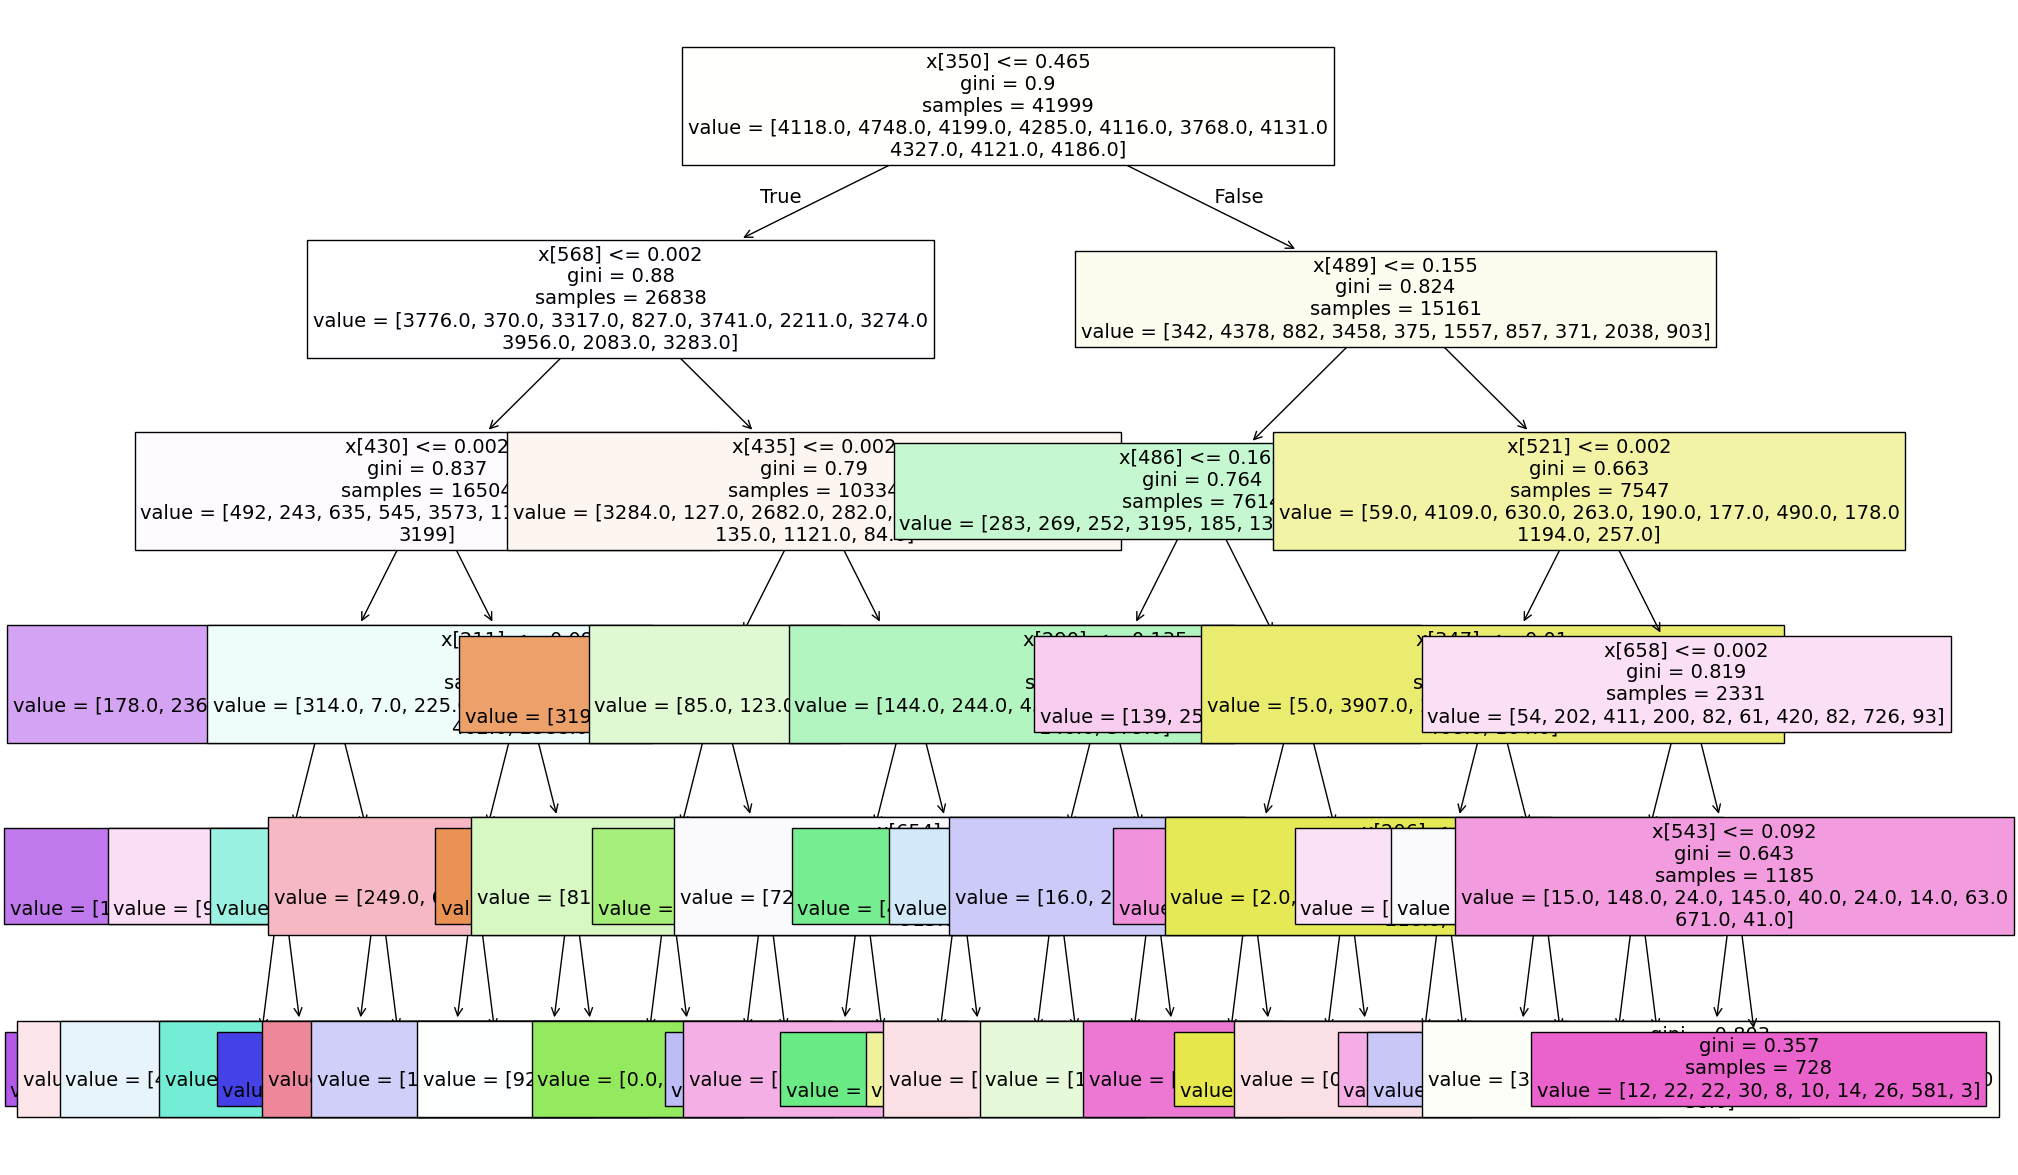

In [21]:
plt.figure(figsize=(20, 15))  # set plot size (denoted in inches)
plot_tree(clf, fontsize=14, filled=True)

#### One tree is good enough... How about an entire forest?
##### https://towardsdatascience.com/understanding-random-forest-58381e0602d2

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    criterion="gini",
    max_depth=5,
    random_state=42,
)
rf.fit(X_flat[ix_train], y[ix_train])

print(f"Accuracy: {rf.score(X_flat[ix_dev], y[ix_dev]):.3f}")

Accuracy: 0.855


# While the score is decent, we can do better! Enter, Neural Networks

In [24]:
from keras import layers, models

In [25]:
model_seq = models.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(units=512, activation="relu"),
        layers.Dense(units=128, activation="relu"),
        layers.Dense(units=32, activation="relu"),
        layers.Dense(units=10, activation="softmax"),
    ]
)

model_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,042 (1.80 MB)

 Trainable params: 472,042 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
input_layer = layers.Input(shape=(784,))
outputs = layers.Dense(units=512, activation="relu")(input_layer)
outputs = layers.Dense(units=128, activation="relu")(outputs)
outputs = layers.Dense(units=32, activation="relu")(outputs)
outputs = layers.Dense(units=10, activation="softmax")(outputs)

model_fun = models.Model(inputs=input_layer, outputs=outputs)
model_fun.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,042 (1.80 MB)

 Trainable params: 472,042 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
class FC_MNIST(models.Model):
    def __init__(self):
        super(FC_MNIST, self).__init__()
        # Creating layers in the initializer
        self.fc2 = layers.Dense(units=128, activation="relu")  # Hidden layer
        self.fc3 = layers.Dense(units=32, activation="relu")  # Hidden layer
        self.fc4 = layers.Dense(units=10, activation="softmax")  # Output layer

    def call(self, input_tensor):
        # Pass input_tensor through the layers sequentially
        x = self.fc2(input_tensor)
        x = self.fc3(x)
        return self.fc4(x)


# Create the input layer
input_layer = layers.Input(shape=(784,))

# Instantiate the custom model and use it on the input layer
model = FC_MNIST()(input_layer)

# Create a complete Keras model by specifying the inputs and outputs
model = models.Model(inputs=input_layer, outputs=model)

# Model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_mnist_1 (FC_MNIST)           │ (None, 10)             │       104,938 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.summary(expand_nested=True)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_mnist_1 (FC_MNIST)           │ (None, 10)             │       104,938 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_11 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_12 (Dense)           │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_13 (Dense)           │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

y_onehot = pd.get_dummies(pd.Series(y)).values  # One-hot encoding (ALTERNATIVE ?)
model_hist = model.fit(
    X_flat[ix_train],
    y_onehot[ix_train],
    epochs=30,
    validation_data=(X_flat[ix_dev], y_onehot[ix_dev]),
)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 727us/step - accuracy: 0.7857 - loss: 0.1328 - val_accuracy: 0.9453 - val_loss: 0.0358
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.9554 - loss: 0.0295 - val_accuracy: 0.9629 - val_loss: 0.0254
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.9699 - loss: 0.0204 - val_accuracy: 0.9629 - val_loss: 0.0244
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.9797 - loss: 0.0148 - val_accuracy: 0.9701 - val_loss: 0.0211
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.9851 - loss: 0.0111 - val_accuracy: 0.9706 - val_loss: 0.0193
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - accuracy: 0.9887 - loss: 0.0087 - val_accuracy: 0.9738 - val_loss: 0.0195
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step - accuracy: 0.9915 - loss: 0.0071 - val_accuracy: 0.9712 - val_loss: 0.0204
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - accuracy: 0.9931 -

In [31]:
from sklearn.metrics import f1_score

score = f1_score(
    y[ix_test],
    model.predict(X_flat[ix_test]).argmax(axis=1),
    average="weighted",
    labels=np.arange(10),
)
print(f"Weighted F1 score: {score:.3f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step
Weighted F1 score: 0.974


#### What if our model stops improving after N epochs? Introducing EarlyStopping...

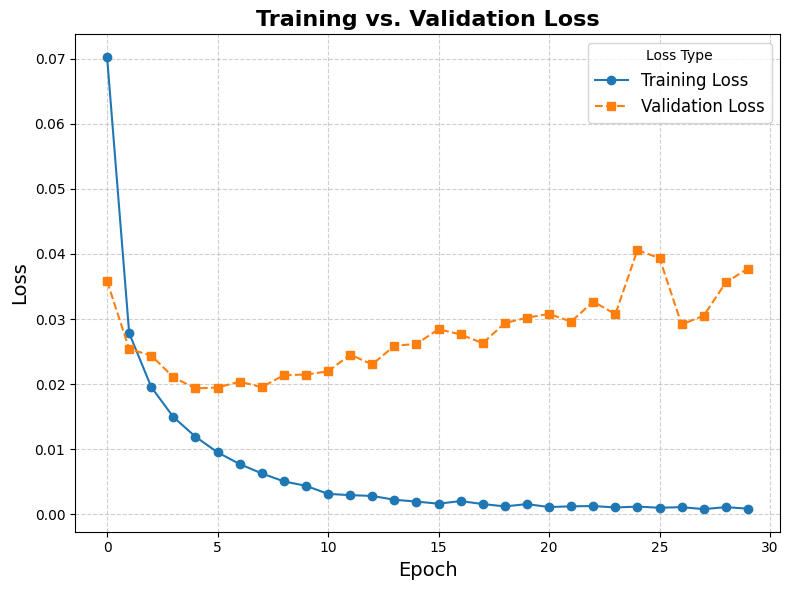

In [32]:
# Create DataFrame from model history
df = pd.DataFrame(
    {
        "Training Loss": model_hist.history["loss"],
        "Validation Loss": model_hist.history["val_loss"],
    }
)

# Plot with customizations
fig, ax = plt.subplots(figsize=(8, 6))

df.plot(ax=ax, style=["-o", "--s"], color=["#1f77b4", "#ff7f0e"])

# Add title and labels
ax.set_title("Training vs. Validation Loss", fontsize=16, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Loss", fontsize=14)

# Adjust legend
ax.legend(title="Loss Type", loc="upper right", fontsize=12)

# Improve readability with gridlines
ax.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
from keras import callbacks

In [34]:
callback = callbacks.EarlyStopping(monitor="val_loss", patience=3)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_hist = model.fit(
    X_flat[ix_train],
    y_onehot[ix_train],
    epochs=30,
    validation_data=(X_flat[ix_dev], y_onehot[ix_dev]),
    callbacks=[callback],
)
model_hist

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.9994 - loss: 8.7873e-04 - val_accuracy: 0.9736 - val_loss: 0.0373
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 651us/step - accuracy: 0.9992 - loss: 0.0012 - val_accuracy: 0.9739 - val_loss: 0.0352
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step - accuracy: 0.9993 - loss: 8.5538e-04 - val_accuracy: 0.9742 - val_loss: 0.0361
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.9991 - loss: 9.1187e-04 - val_accuracy: 0.9761 - val_loss: 0.0346
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - accuracy: 0.9998 - loss: 2.9246e-04 - val_accuracy: 0.9729 - val_loss: 0.0390
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.9990 - loss: 0.0012 - val_accuracy: 0.9743 - val_loss: 0.0387
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step - accuracy: 0.9996 - loss: 5.9384e-04 - val_accuracy: 0.9751 - val_loss: 0.0376


#### "How Neural Networks Learn?" Starter Pack
  * ##### What is Gradient Descent: https://www.ibm.com/topics/gradient-descent#:~:text=Gradient%20descent%20is%20an%20optimization,each%20iteration%20of%20parameter%20updates.
  * ##### Calculus on Computational Graphs: Backpropagation: https://colah.github.io/posts/2015-08-Backprop/

# Our model Performs very good (on par with state-of-the-art)! Can we do any better? 
### Let's try a larger Neural Network... ResNet101 v2 and VGG16 Trained on ImageNet (https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/)

In [35]:
from keras.applications.resnet_v2 import (
    ResNet101V2,
    ResNet50V2,
    preprocess_input,
    decode_predictions,
)

In [36]:
resnet_model = ResNet101V2()

In [37]:
resnet_model.summary(expand_nested=False)

Model: "resnet101v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 44,675,560 (170.42 MB)

 Trainable params: 44,577,896 (170.05 MB)

 Non-trainable params: 97,664 (381.50 KB)

In [38]:
from keras import utils

In [39]:
img = utils.load_img("data/dog.jpg", target_size=(224, 224))
x = utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [41]:
# np.argmax(resnet_model(x))
decode_predictions(resnet_model(x).numpy(), top=10)

[[('n02099712', 'Labrador_retriever', np.float32(0.72680473)),
  ('n02087394', 'Rhodesian_ridgeback', np.float32(0.2518791)),
  ('n02090379', 'redbone', np.float32(0.005626991)),
  ('n02099601', 'golden_retriever', np.float32(0.0054997355)),
  ('n02099849', 'Chesapeake_Bay_retriever', np.float32(0.0033572589)),
  ('n02100583', 'vizsla', np.float32(0.0028879954)),
  ('n02108422', 'bull_mastiff', np.float32(0.0013202877)),
  ('n02089973', 'English_foxhound', np.float32(0.0010321572)),
  ('n02115641', 'dingo', np.float32(0.00027591997)),
  ('n02104029', 'kuvasz', np.float32(8.681558e-05))]]

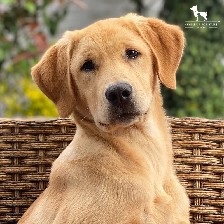

In [45]:
img

### The model has over 44M trainable parameters, which sometimes is not feasible to train. However, we can use its already aquired knowledge, and adapt (fine-tune) it to other domains

In [42]:
from keras.applications.vgg16 import VGG16, preprocess_input

In [43]:
input_layer = layers.Input(shape=(48, 48, 3))
pre_trained_net = VGG16(weights="imagenet", input_tensor=input_layer, include_top=False)

pre_trained_net.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
pre_trained_net.layers

[<InputLayer name=input_layer_4, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [54]:
layer_names = [layer.name for layer in pre_trained_net.layers]
layer_names.index("block5_conv1")

15

In [50]:
pre_trained_net.trainable = True  # Freeze the entire model

# If you want to freeze certain layers (WARNING: the neural networks must NOT be frozen)
for layer in pre_trained_net.layers[15:]:
    layer.trainable = False

In [51]:
pre_trained_net.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 555,328 (2.12 MB)

 Non-trainable params: 14,159,360 (54.01 MB)

In [52]:
class FC_MNIST_FineTuned(models.Model):
    def __init__(self, feature_extractor):
        super(FC_MNIST_FineTuned, self).__init__()
        # creating layers in initializer
        self.feature_extractor = feature_extractor
        self.flat = layers.Flatten()
        self.fc2 = layers.Dense(units=128, activation="relu")
        self.fc3 = layers.Dense(units=32, activation="relu")
        self.fc4 = layers.Dense(units=10, activation="softmax")

    def call(self, input_tensor):
        return self.fc4(self.fc3(self.fc2(self.flat(self.feature_extractor(input_tensor)))))


model = FC_MNIST_FineTuned(pre_trained_net)
model.build((None, 48, 48, 3))
model.summary()

/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:395: UserWarning: `build()` was called on layer 'fc_mnist__fine_tuned', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "fc_mnist__fine_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 555,328 (2.12 MB)

 Non-trainable params: 14,159,360 (54.01 MB)

In [53]:
np.expand_dims(X, -1).shape

(60000, 28, 28, 1)

In [54]:
X_rgb = np.repeat(np.expand_dims(X, -1), 3, -1)

In [55]:
X_rgb.shape

(60000, 28, 28, 3)

In [56]:
X_rgb_prepped = np.array(
    [
        preprocess_input(
            utils.img_to_array(utils.array_to_img(X_i, scale=False).resize((48, 48)))
        )
        for X_i in X_rgb
    ]
)

In [62]:
batch_size = 128
epochs = 45

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

early_stop = callbacks.EarlyStopping(monitor="loss", patience=7)
model.fit(
    X_rgb_prepped[ix_train],
    y_onehot[ix_train],
    batch_size=batch_size,
    validation_data=(X_rgb_prepped[ix_dev], y_onehot[ix_dev]),
    epochs=epochs,
    callbacks=[early_stop],
)

Epoch 1/45


/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_392']
Received: inputs=Tensor(shape=(None, 48, 48, 3))
  warnings.warn(msg)


329/329 ━━━━━━━━━━━━━━━━━━━━ 251s 760ms/step - accuracy: 0.1089 - loss: 3.8497 - val_accuracy: 0.1110 - val_loss: 2.3014
Epoch 2/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 311s 946ms/step - accuracy: 0.1133 - loss: 2.3013 - val_accuracy: 0.1110 - val_loss: 2.3013
Epoch 3/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 270s 821ms/step - accuracy: 0.1135 - loss: 2.3012 - val_accuracy: 0.1110 - val_loss: 2.3013
Epoch 4/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 271s 825ms/step - accuracy: 0.1118 - loss: 2.3013 - val_accuracy: 0.1110 - val_loss: 2.3012
Epoch 5/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 4275s 13s/step - accuracy: 0.1141 - loss: 2.3009 - val_accuracy: 0.1110 - val_loss: 2.3013
Epoch 6/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 6744s 17s/step - accuracy: 0.1113 - loss: 2.3014 - val_accuracy: 0.1110 - val_loss: 2.3013
Epoch 7/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 247s 752ms/step - accuracy: 0.1158 - loss: 2.3008 - val_accuracy: 0.1110 - val_loss: 2.3013
Epoch 8/45
329/329 ━━━━━━━━━━━━━━━━━━━━ 252s 767ms/step - accuracy: 0.1124 - loss: 2.3013

In [63]:
score = model.evaluate(X_rgb_prepped[ix_test], y_onehot[ix_test], verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

KeyboardInterrupt: 

In [57]:
model_out = model.predict(X_rgb_prepped[ix_test][8:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_395']
Received: inputs=Tensor(shape=(2, 48, 48, 3))
  warnings.warn(msg)


In [58]:
model_out.shape

(2, 10)

In [ ]:
np.argmax(mdoel_out, axis=1)

array([9, 9])

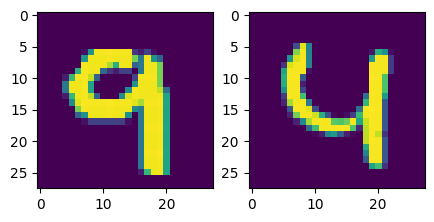

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(5, 10))

ax[0].imshow(X[ix_test][8])
ax[1].imshow(X[ix_test][9])

plt.show()

In [61]:
np.argmax(y_onehot[ix_test][8:10], axis=1)

array([9, 4])